Loading and preparing data...
Dataset shape (tanpa netral): (2719, 3)
Label distribution:
label
positif    1385
negatif    1334
Name: count, dtype: int64
Creating TF-IDF features...
Feature matrix shape: (2719, 5000)
Training models...
Optimizing hyperparameters...
Best KNN params: {'metric': 'cosine', 'n_neighbors': 7, 'weights': 'distance'}
Best SVM params: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
KNN training time: 0.0158s
SVM training time: 1.5688s
Evaluating models...

KNN Results:
 Accuracy: 0.8824
 Precision: 0.8830
 Recall: 0.8824
 F1-Score: 0.8822
 CV: 0.8310 ± 0.0284

SVM Results:
 Accuracy: 0.9357
 Precision: 0.9362
 Recall: 0.9357
 F1-Score: 0.9357
 CV: 0.8714 ± 0.0244

Generating visualizations…


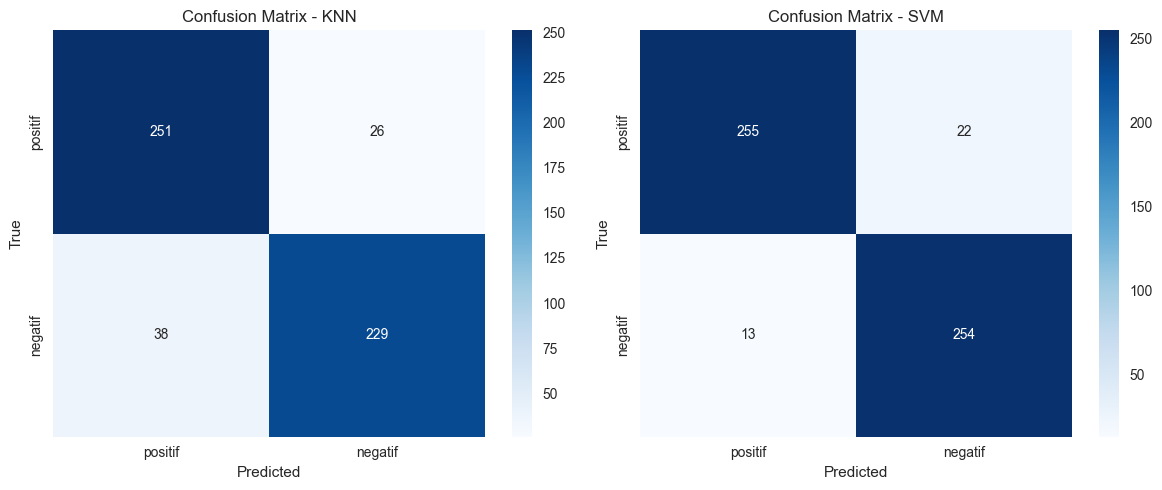

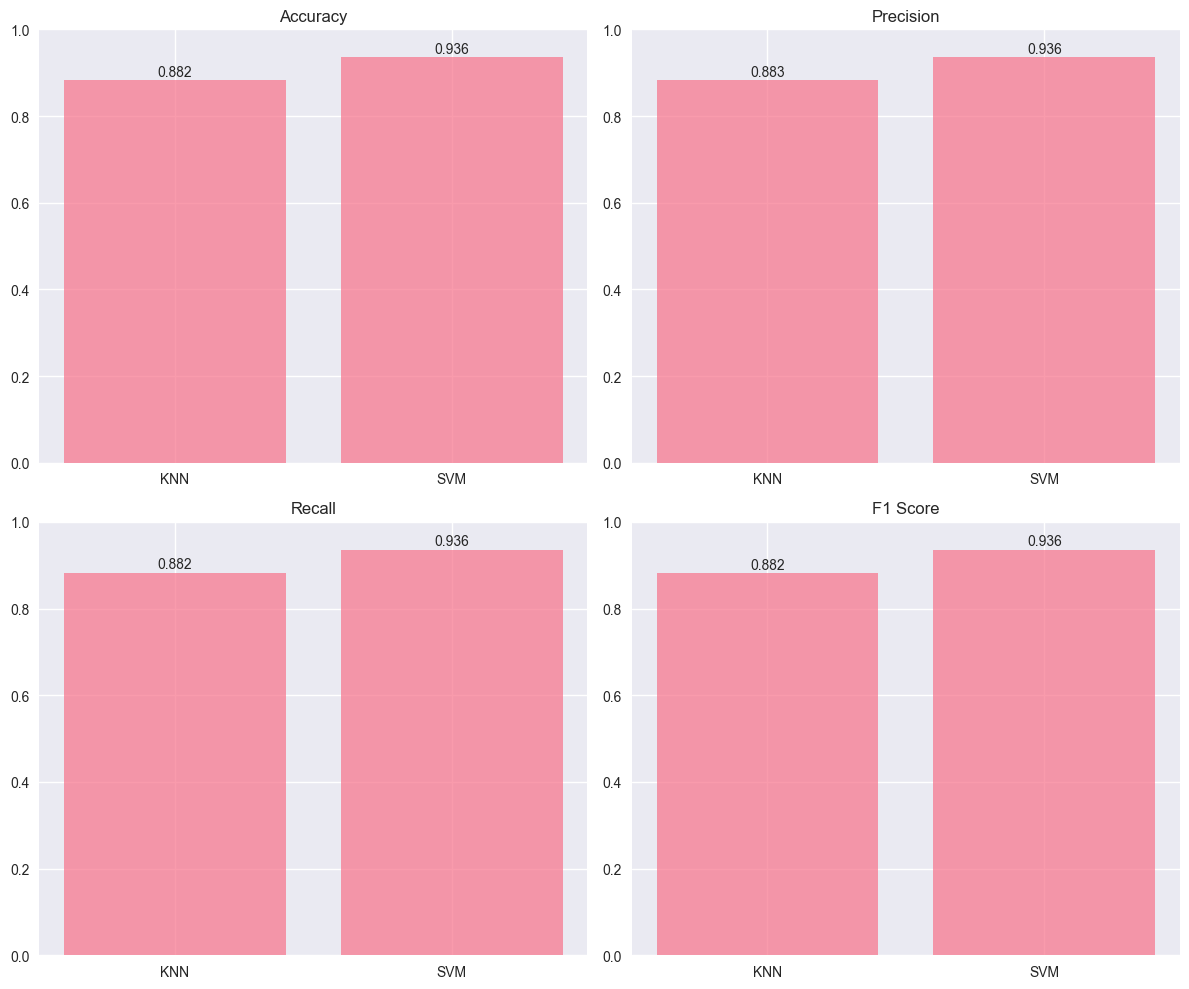

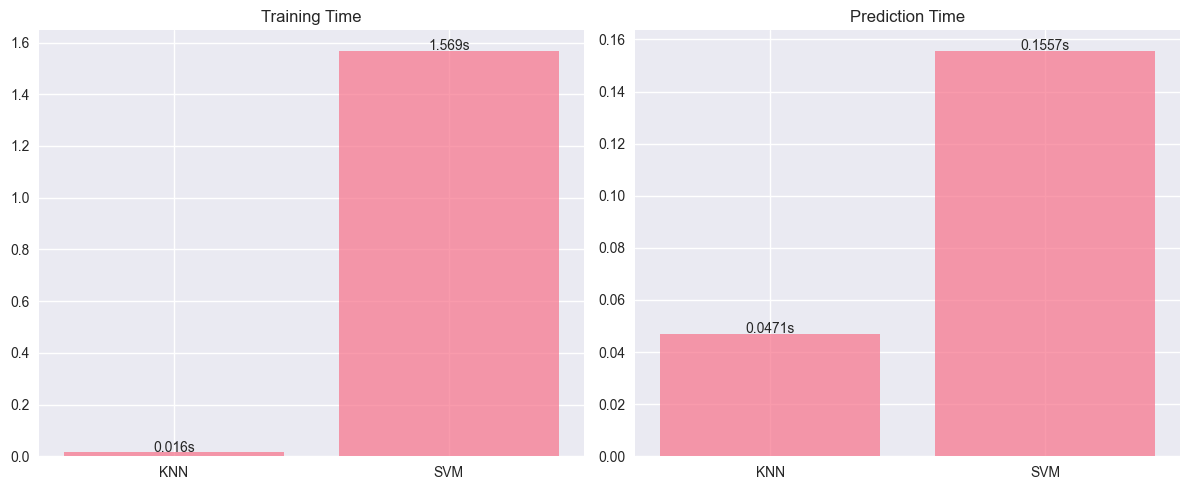

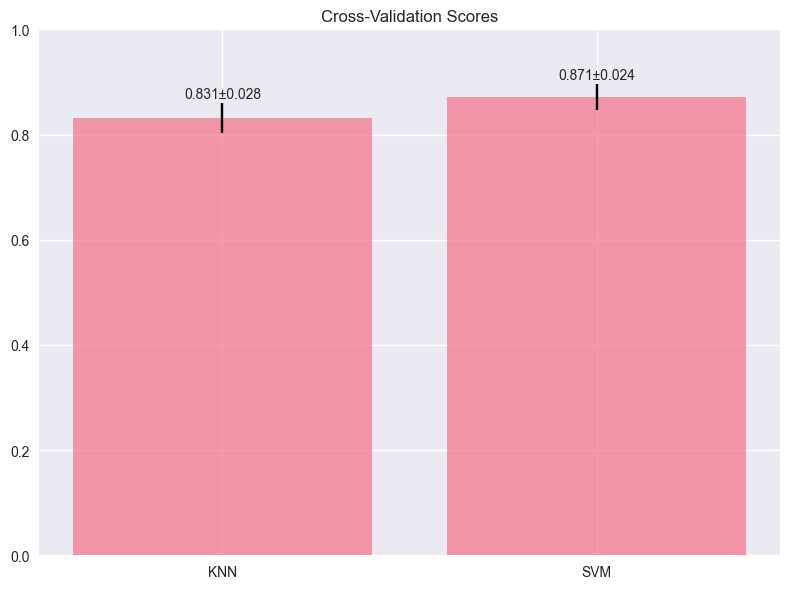

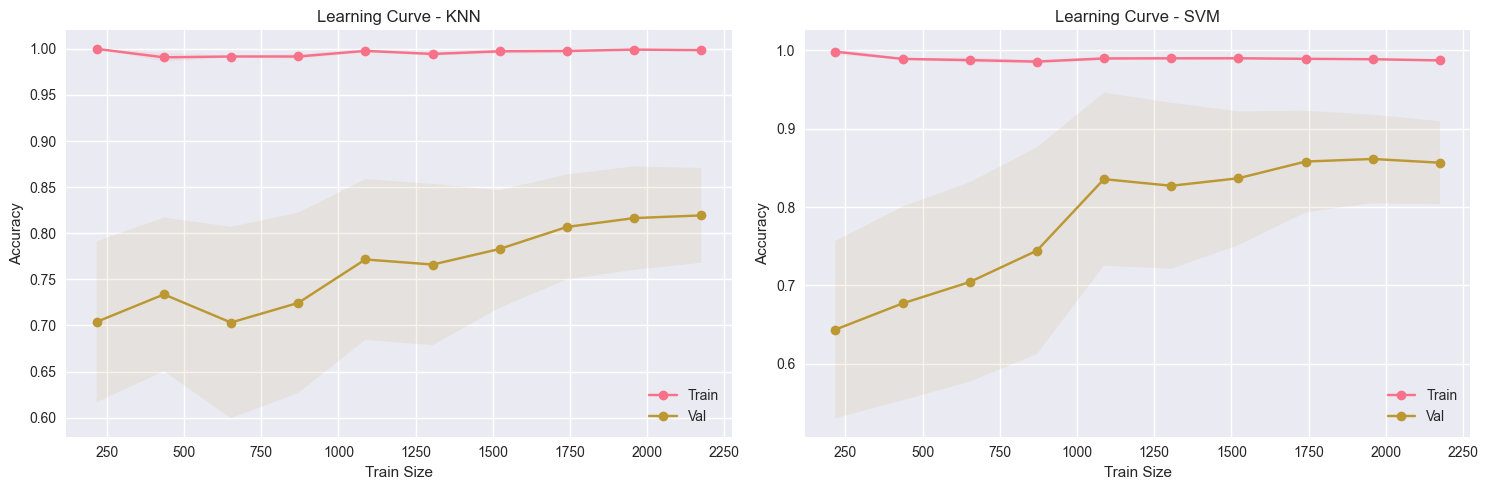


Menampilkan scatter plot fitur (2D) - Data Latih:


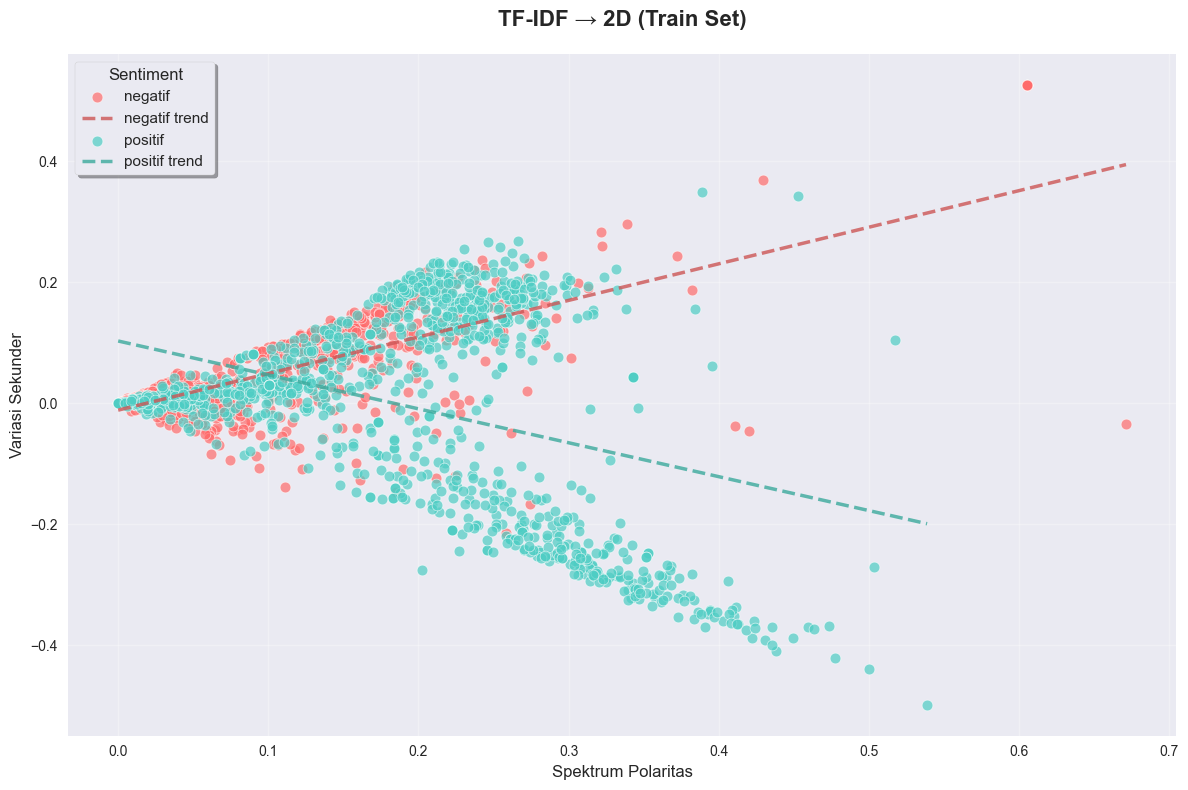


Menampilkan scatter plot fitur (2D) - Prediksi SVM:


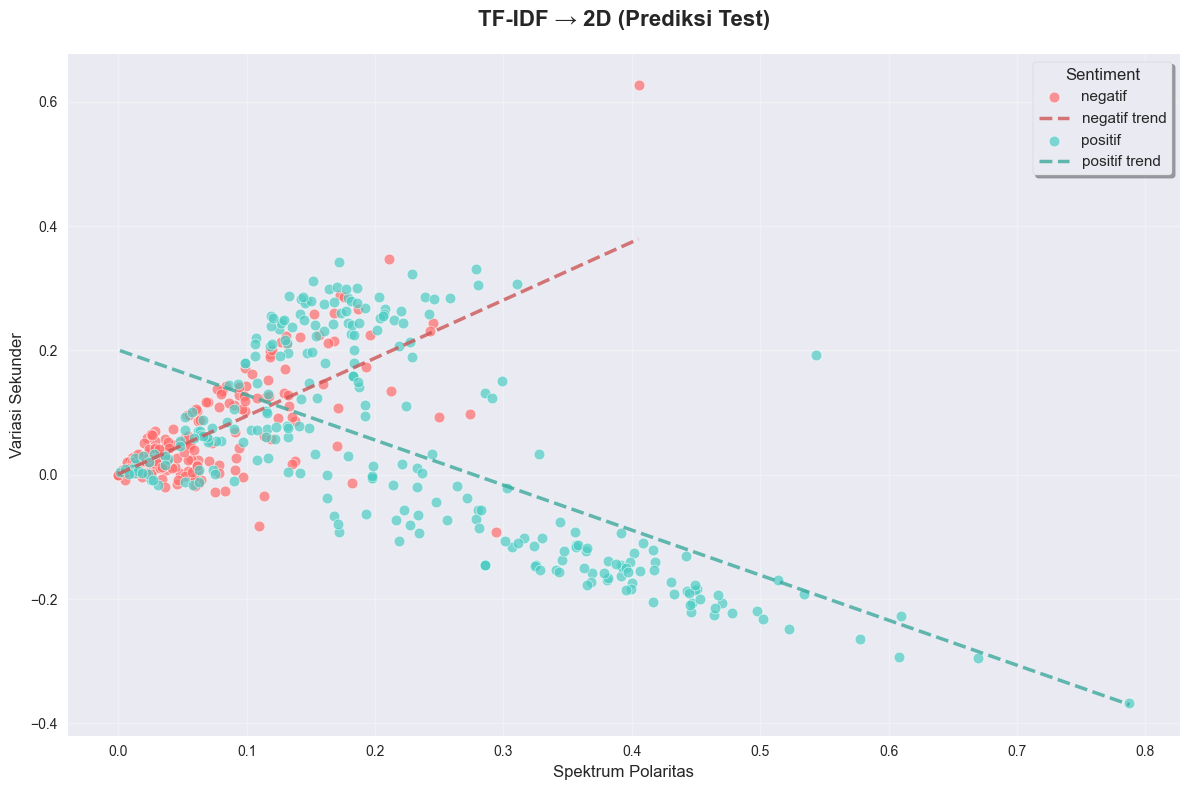


DETAILED MODEL COMPARISON REPORT

KNN Model:
------------------------------
Accuracy: 0.8824
Precision: 0.8830
Recall: 0.8824
F1-Score: 0.8822
CV: 0.8310 ± 0.0284
Training Time: 0.0158s
Prediction Time: 0.0471s

SVM Model:
------------------------------
Accuracy: 0.9357
Precision: 0.9362
Recall: 0.9357
F1-Score: 0.9357
CV: 0.8714 ± 0.0244
Training Time: 1.5688s
Prediction Time: 0.1557s

                       RECOMMENDATION                       
Best Accuracy   : SVM (0.9357)
Best F1-Score   : SVM (0.9357)
Fastest Training: KNN (0.0158s)
Fastest Predict : KNN (0.0471s)


In [60]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV, 
    StratifiedKFold, learning_curve
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, 
    precision_recall_fscore_support, roc_curve, auc, 
    precision_recall_curve
)
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline
import nltk
from nltk.corpus import stopwords
import warnings
import time
from collections import Counter

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

class TextSentimentClassifier:
    def __init__(self):
        # lexicon positif & negatif
        self.pos_words = [
            'senang', 'bagus', 'mantap', 'puas', 'support', 'dukung', 'positif',
            'mendukung', 'solusi nyata', 'sehat', 'sekarang bisa', 'harapan baru',
            'naik', 'merasakan manfaat', 'diakui', 'terasa nyata', 'optimal',
            'berdampak langsung', 'berdampak baik', 'ramah', 'sukses',
            'membuka peluang', 'prestasi', 'terbantu', 'terima kasih', 'mudah',
            'cepat', 'bermanfaat', 'gratis', 'lancar', 'responsif', 'inovatif',
            'solutif', 'memuaskan', 'hebat', 'luar biasa', 'terjangkau'
        ]
        self.neg_words = [
            'sedih', 'buruk', 'kecewa', 'menolak', 'negatif', 'kritik', 'protes',
            'sakit', 'keracunan', 'korupsi', 'sulit', 'lambat', 'masalah',
            'keluhan', 'bingung', 'tidak jelas', 'mahal', 'berbelit-belit',
            'tidak berfungsi', 'antre', 'dipersulit', 'tidak adil', 'menunggu',
            'belum beres', 'blm beres', 'ga guna', 'gaguna', 'tidak dapat',
            'investigasi', 'goreng', 'putus asa', 'jatah', 'penyelewengan',
            'belok', 'bubar', 'antek', 'waste', 'kurang', 'tekor', 'bohong',
            'boong', 'miskin', 'nunggak', 'hutang', 'utang', 'bazer', 'buzzer',
            'bocor', 'maling', 'panas', 'serem', 'omon', 'ok gas', 'tidak setuju',
            'tdk setuju', 'ordal', 'orang dalam', 'tega', 'joged', 'mangkrak',
            'maksa', 'ga terima', 'g terima', 'profit', 'gak dibayar',
            'g dibayar', 'gk dibayar', 'ga guna', 'g guna', 'omon',
            'tidak ada', 'sia', 'keracunan', 'bodoh', 'bodoh2', 'wkwkwkwk',
            'antek asing', 'gak peduli', 'belum terlihat'
        ]
        self.vectorizer = None
        self.models = {}
        self.results = {}

    def auto_label(self, text):
        t = str(text).lower()
        pos_count = sum(1 for w in self.pos_words if w in t)
        neg_count = sum(1 for w in self.neg_words if w in t)
        if pos_count > neg_count:
            return 'positif'
        elif neg_count > pos_count:
            return 'negatif'
        else:
            return 'netral'

    def preprocess_text(self, text):
        try:
            nltk.download('stopwords', quiet=True)
            stop_words = set(stopwords.words('indonesian'))
        except:
            stop_words = set()
        t = str(text).lower()
        t = re.sub(r"http\S+|www\.\S+|@\w+", "", t)
        t = re.sub(r"[^a-z0-9\s]", " ", t)
        t = re.sub(r'\s+', ' ', t)
        tokens = [tok for tok in t.split() if tok not in stop_words and len(tok) > 2]
        return ' '.join(tokens)

    def load_and_prepare_data(self, filepath):
        print("Loading and preparing data...")
        df = pd.read_csv(filepath)
        df['label'] = df['full_text'].apply(self.auto_label)
        df = df[df['label'] != 'netral']
        df['clean_text'] = df['full_text'].apply(self.preprocess_text)
        df = df[df['clean_text'].str.len() > 0]
        print(f"Dataset shape (tanpa netral): {df.shape}")
        print(f"Label distribution:\n{df['label'].value_counts()}")
        return df

    def create_features(self, df, max_features=5000):
        print("Creating TF-IDF features...")
        self.vectorizer = TfidfVectorizer(
            max_features=max_features,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95
        )
        X = self.vectorizer.fit_transform(df['clean_text'])
        y = df['label'].values
        print(f"Feature matrix shape: {X.shape}")
        return X, y

    def optimize_hyperparameters(self, X_train, y_train):
        print("Optimizing hyperparameters...")
        knn_params = {
            'n_neighbors': [3, 5, 7, 9, 11],
            'weights': ['uniform', 'distance'],
            'metric': ['euclidean', 'manhattan', 'cosine']
        }
        knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5,
                                scoring='accuracy', n_jobs=-1)
        knn_grid.fit(X_train, y_train)

        svm_params = {
            'C': [0.1, 1, 10, 100],
            'kernel': ['linear', 'rbf'],
            'gamma': ['scale', 'auto']
        }
        svm_grid = GridSearchCV(SVC(probability=True), svm_params, cv=5,
                                scoring='accuracy', n_jobs=-1)
        svm_grid.fit(X_train, y_train)

        print(f"Best KNN params: {knn_grid.best_params_}")
        print(f"Best SVM params: {svm_grid.best_params_}")
        return knn_grid.best_estimator_, svm_grid.best_estimator_

    def train_models(self, X_train, y_train, optimize=True):
        print("Training models...")
        if optimize:
            knn_best, svm_best = self.optimize_hyperparameters(X_train, y_train)
            self.models['KNN'] = knn_best
            self.models['SVM'] = svm_best
        else:
            self.models['KNN'] = KNeighborsClassifier(n_neighbors=5)
            self.models['SVM'] = SVC(kernel='linear', C=1.0, probability=True)

        for name, model in self.models.items():
            start_time = time.time()
            model.fit(X_train, y_train)
            t = time.time() - start_time
            self.results[name] = {'training_time': t}
            print(f"{name} training time: {t:.4f}s")

    def evaluate_models(self, X_test, y_test, class_labels):
        print("Evaluating models...")
        for name, model in self.models.items():
            start = time.time()
            y_pred = model.predict(X_test)
            y_proba = model.predict_proba(X_test)
            pred_t = time.time() - start

            acc = accuracy_score(y_test, y_pred)
            prec, rec, f1, _ = precision_recall_fscore_support(
                y_test, y_pred, labels=class_labels,
                average='weighted', zero_division=0
            )
            cv = cross_val_score(model, X_test, y_test, cv=5)

            self.results[name].update({
                'accuracy': acc,
                'precision': prec,
                'recall': rec,
                'f1_score': f1,
                'cv_mean': cv.mean(),
                'cv_std': cv.std(),
                'prediction_time': pred_t,
                'y_pred': y_pred,
                'confusion_matrix': confusion_matrix(
                    y_test, y_pred, labels=class_labels)
            })

            print(f"\n{name} Results:")
            print(f" Accuracy: {acc:.4f}")
            print(f" Precision: {prec:.4f}")
            print(f" Recall: {rec:.4f}")
            print(f" F1-Score: {f1:.4f}")
            print(f" CV: {cv.mean():.4f} ± {cv.std():.4f}")

    def plot_confusion_matrices(self, class_labels):
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        for i, (name, res) in enumerate(self.results.items()):
            cm = res['confusion_matrix']
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                        xticklabels=class_labels,
                        yticklabels=class_labels,
                        ax=axes[i])
            axes[i].set_title(f'Confusion Matrix - {name}')
            axes[i].set_xlabel('Predicted')
            axes[i].set_ylabel('True')
        plt.tight_layout()
        plt.show()

    def plot_metrics_comparison(self):
        metrics = ['accuracy', 'precision', 'recall', 'f1_score']
        names = list(self.results.keys())
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        axes = axes.ravel()
        for i, m in enumerate(metrics):
            vals = [self.results[n][m] for n in names]
            bars = axes[i].bar(names, vals, alpha=0.7)
            axes[i].set_title(m.replace('_', ' ').title())
            axes[i].set_ylim(0, 1)
            for bar, v in zip(bars, vals):
                axes[i].text(bar.get_x()+bar.get_width()/2,
                             v+0.01, f"{v:.3f}", ha='center')
        plt.tight_layout()
        plt.show()

    def plot_performance_metrics(self):
        names = list(self.results.keys())
        train_t = [self.results[n]['training_time'] for n in names]
        pred_t = [self.results[n]['prediction_time'] for n in names]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
        bars1 = ax1.bar(names, train_t, alpha=0.7)
        ax1.set_title('Training Time')
        for b, t in zip(bars1, train_t):
            ax1.text(b.get_x()+b.get_width()/2, t+0.001,
                     f"{t:.3f}s", ha='center')
        bars2 = ax2.bar(names, pred_t, alpha=0.7)
        ax2.set_title('Prediction Time')
        for b, t in zip(bars2, pred_t):
            ax2.text(b.get_x()+b.get_width()/2, t+0.0001,
                     f"{t:.4f}s", ha='center')
        plt.tight_layout()
        plt.show()

    def plot_cross_validation_scores(self):
        names = list(self.results.keys())
        means = [self.results[n]['cv_mean'] for n in names]
        stds = [self.results[n]['cv_std'] for n in names]
        plt.figure(figsize=(8, 6))
        bars = plt.bar(names, means, yerr=stds, capsize=5, alpha=0.7)
        plt.title('Cross-Validation Scores')
        plt.ylim(0, 1)
        for b, m, s in zip(bars, means, stds):
            plt.text(b.get_x()+b.get_width()/2, m+s+0.01,
                     f"{m:.3f}±{s:.3f}", ha='center')
        plt.tight_layout()
        plt.show()

    def plot_learning_curves(self, X, y):
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        for i, (name, model) in enumerate(self.models.items()):
            sizes, train_s, val_s = learning_curve(
                model, X, y, cv=5, n_jobs=-1,
                train_sizes=np.linspace(0.1, 1.0, 10)
            )
            train_mean = np.mean(train_s, axis=1)
            train_std = np.std(train_s, axis=1)
            val_mean = np.mean(val_s, axis=1)
            val_std = np.std(val_s, axis=1)

            axes[i].plot(sizes, train_mean, 'o-', label='Train')
            axes[i].fill_between(sizes, train_mean-train_std,
                                 train_mean+train_std, alpha=0.1)
            axes[i].plot(sizes, val_mean, 'o-', label='Val')
            axes[i].fill_between(sizes, val_mean-val_std,
                                 val_mean+val_std, alpha=0.1)
            axes[i].set_title(f'Learning Curve - {name}')
            axes[i].set_xlabel('Train Size')
            axes[i].set_ylabel('Accuracy')
            axes[i].legend()
            axes[i].grid(True)
        plt.tight_layout()
        plt.show()

    def plot_scatter_2d(self, X_sparse, y, title="2D Scatter Plot of Text Vectors (via SVD)"):
        """Plot 2D scatter plot of text vectors using SVD dimensionality reduction"""
        svd = TruncatedSVD(n_components=2, random_state=42)
        X2d = svd.fit_transform(X_sparse)

        # Mapping warna untuk setiap label
        unique_labels = list(set(y))
        colors = ['#FF6B6B', '#4ECDC4']  # Merah coral untuk negatif, Teal untuk positif
        trend_colors = ['#CC5555', '#3BA99C']  # Warna lebih gelap untuk garis tren
        color_map = {label: colors[i] for i, label in enumerate(sorted(unique_labels))}
        trend_color_map = {label: trend_colors[i] for i, label in enumerate(sorted(unique_labels))}
        
        plt.figure(figsize=(12, 8))
        
        # Plot setiap label dengan warna berbeda dan garis tren
        for label in unique_labels:
            mask = y == label
            x_data = X2d[mask, 0]
            y_data = X2d[mask, 1]
            
            # Plot scatter points
            plt.scatter(x_data, y_data, 
                       c=color_map[label], 
                       label=label,
                       alpha=0.7, 
                       s=60,  # Ukuran marker lebih besar
                       edgecolors='white',  # Border putih
                       linewidth=0.5)
            
            # Tambahkan garis tren (linear regression)
            if len(x_data) > 1:  # Pastikan ada cukup data untuk tren
                # Hitung koefisien linear regression
                coeffs = np.polyfit(x_data, y_data, 1)
                trend_line = np.poly1d(coeffs)
                
                # Buat x values untuk garis tren
                x_trend = np.linspace(x_data.min(), x_data.max(), 100)
                y_trend = trend_line(x_trend)
                
                # Plot garis tren
                plt.plot(x_trend, y_trend, 
                        color=trend_color_map[label], 
                        linestyle='--', 
                        linewidth=2.5,
                        alpha=0.8,
                        label=f'{label} trend')
        
        plt.title(title, fontsize=16, fontweight='bold', pad=20)
        plt.xlabel('Spektrum Polaritas', fontsize=12)
        plt.ylabel('Variasi Sekunder', fontsize=12)
        plt.legend(title='Sentiment', fontsize=11, title_fontsize=12, 
                  frameon=True, fancybox=True, shadow=True)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    def generate_detailed_report(self):
        print("\n" + "="*60)
        print("DETAILED MODEL COMPARISON REPORT")
        print("="*60)
        for name, res in self.results.items():
            print(f"\n{name} Model:")
            print("-"*30)
            print(f"Accuracy: {res['accuracy']:.4f}")
            print(f"Precision: {res['precision']:.4f}")
            print(f"Recall: {res['recall']:.4f}")
            print(f"F1-Score: {res['f1_score']:.4f}")
            print(f"CV: {res['cv_mean']:.4f} ± {res['cv_std']:.4f}")
            print(f"Training Time: {res['training_time']:.4f}s")
            print(f"Prediction Time: {res['prediction_time']:.4f}s")

        print(f"\n{'RECOMMENDATION':^60}")
        best_acc = max(self.results.items(), key=lambda x: x[1]['accuracy'])
        best_f1 = max(self.results.items(), key=lambda x: x[1]['f1_score'])
        fastest_train = min(self.results.items(), key=lambda x: x[1]['training_time'])
        fastest_pred = min(self.results.items(), key=lambda x: x[1]['prediction_time'])
        print(f"Best Accuracy   : {best_acc[0]} ({best_acc[1]['accuracy']:.4f})")
        print(f"Best F1-Score   : {best_f1[0]} ({best_f1[1]['f1_score']:.4f})")
        print(f"Fastest Training: {fastest_train[0]} ({fastest_train[1]['training_time']:.4f}s)")
        print(f"Fastest Predict : {fastest_pred[0]} ({fastest_pred[1]['prediction_time']:.4f}s)")


def main():
    classifier = TextSentimentClassifier()

    # 1. Load & prepare data
    df = classifier.load_and_prepare_data('Data1_fix_cleaning.csv')

    # 2. Create TF-IDF features
    X, y = classifier.create_features(df)

    # 3. Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y)

    class_labels = ['positif', 'negatif']

    # 4. Train
    classifier.train_models(X_train, y_train, optimize=True)

    # 5. Evaluate
    classifier.evaluate_models(X_test, y_test, class_labels)

    # 6. Visualizations
    print("\nGenerating visualizations…")
    classifier.plot_confusion_matrices(class_labels)
    classifier.plot_metrics_comparison()
    classifier.plot_performance_metrics()
    classifier.plot_cross_validation_scores()
    classifier.plot_learning_curves(X, y)

    # 7. Scatter plots
    print("\nMenampilkan scatter plot fitur (2D) - Data Latih:")
    classifier.plot_scatter_2d(X_train, y_train, title="TF-IDF → 2D (Train Set)")

    print("\nMenampilkan scatter plot fitur (2D) - Prediksi SVM:")
    y_test_pred = classifier.models['SVM'].predict(X_test)
    classifier.plot_scatter_2d(X_test, y_test_pred, title="TF-IDF → 2D (Prediksi Test)")

    # 8. Detailed report
    classifier.generate_detailed_report()


if __name__ == "__main__":
    main()

In [64]:
import matplotlib.pyplot as plt
import pandas as pd

class SentimentVisualizer:
    def plot_sentiment_distribution(self, df, title="Distribusi Sentimen Dataset"):
        """Plot bar chart untuk distribusi sentimen dalam dataset"""
        if 'label' not in df.columns or df['label'].empty:
            print("Kolom 'label' tidak ditemukan atau kosong.")
            return

        # Hitung distribusi sentimen
        sentiment_counts = df['label'].value_counts()
        sentiment_percentages = sentiment_counts / len(df) * 100

        # Setup plot
        plt.figure(figsize=(10, 6))

        # Warna default (diatur agar menyesuaikan jumlah label unik)
        default_colors = ['#4ECDC4', '#FF6B6B', '#FFA500', '#C44DFF', '#00BFFF']
        colors = default_colors[:len(sentiment_counts)]

        # Buat bar chart
        bars = plt.bar(sentiment_counts.index, sentiment_counts.values,
                       color=colors, alpha=0.8, edgecolor='white', linewidth=1.5)

        # Tambahkan label nilai di atas bar
        for bar, count, percentage in zip(bars, sentiment_counts.values, sentiment_percentages.values):
            plt.text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + max(sentiment_counts.values) * 0.01,
                     f'{count:,}\n({percentage:.1f}%)',
                     ha='center', va='bottom', fontweight='bold', fontsize=11)

        # Styling
        plt.title(title, fontsize=16, fontweight='bold', pad=20)
        plt.xlabel('Sentimen', fontsize=12)
        plt.ylabel('Jumlah Data', fontsize=12)
        plt.grid(True, alpha=0.3, axis='y')
        plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

        # Tambahkan statistik summary di bawah plot
        total_data = len(df)
        ratio_str = " | ".join([
            f"{label.capitalize()}: {percentage:.1f}%" for label, percentage in sentiment_percentages.items()
        ])
        stats_text = f"Total Data: {total_data:,} | {ratio_str}"
        plt.figtext(0.5, 0.02, stats_text, ha='center', fontsize=10, style='italic')

        plt.tight_layout()
        plt.show()

        # Print summary
        print(f"\n{'=' * 50}")
        print(f"{'DISTRIBUSI SENTIMEN DATASET':^50}")
        print(f"{'=' * 50}")
        print(f"Total Data: {total_data:,}")
        for label in sentiment_counts.index:
            print(f"{label.capitalize()}: {sentiment_counts[label]:,} ({sentiment_percentages[label]:.1f}%)")

        # Analisis keseimbangan dataset
        if len(sentiment_percentages) >= 2:
            balance_ratio = min(sentiment_percentages.values) / max(sentiment_percentages.values)
            if balance_ratio >= 0.8:
                balance_status = "Sangat Seimbang"
            elif balance_ratio >= 0.6:
                balance_status = "Cukup Seimbang"
            elif balance_ratio >= 0.4:
                balance_status = "Kurang Seimbang"
            else:
                balance_status = "Tidak Seimbang"
            print(f"Status Keseimbangan: {balance_status} (Rasio: {balance_ratio:.2f})")
        else:
            print("Tidak bisa menghitung keseimbangan: hanya ada satu label.")

        print(f"{'=' * 50}")

    def plot_sentiment_distribution_comparison(self, df_original, df_processed, 
                                               title="Perbandingan Distribusi Sentimen"):
        """Plot perbandingan distribusi sentimen antara data asli dan data yang diproses"""
        if 'label' not in df_original.columns or 'label' not in df_processed.columns:
            print("Kolom 'label' tidak ditemukan di salah satu dataframe.")
            return

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

        # Data asli
        original_counts = df_original['label'].value_counts()
        colors_original = ['#4ECDC4', '#FF6B6B', '#FFA500', '#C44DFF', '#00BFFF'][:len(original_counts)]

        bars1 = ax1.bar(original_counts.index, original_counts.values,
                        color=colors_original, alpha=0.8, edgecolor='white', linewidth=1.5)

        for bar, count in zip(bars1, original_counts.values):
            percentage = (count / len(df_original)) * 100
            ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(original_counts.values) * 0.01,
                     f'{count:,}\n({percentage:.1f}%)',
                     ha='center', va='bottom', fontweight='bold', fontsize=10)

        ax1.set_title('Data Asli', fontsize=14, fontweight='bold')
        ax1.set_xlabel('Sentimen')
        ax1.set_ylabel('Jumlah Data')
        ax1.grid(True, alpha=0.3, axis='y')
        ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

        # Data diproses
        processed_counts = df_processed['label'].value_counts()
        colors_processed = ['#4ECDC4', '#FF6B6B', '#FFA500', '#C44DFF', '#00BFFF'][:len(processed_counts)]

        bars2 = ax2.bar(processed_counts.index, processed_counts.values,
                        color=colors_processed, alpha=0.8, edgecolor='white', linewidth=1.5)

        for bar, count in zip(bars2, processed_counts.values):
            percentage = (count / len(df_processed)) * 100
            ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(processed_counts.values) * 0.01,
                     f'{count:,}\n({percentage:.1f}%)',
                     ha='center', va='bottom', fontweight='bold', fontsize=10)

        ax2.set_title('Data Diproses', fontsize=14, fontweight='bold')
        ax2.set_xlabel('Sentimen')
        ax2.set_ylabel('Jumlah Data')
        ax2.grid(True, alpha=0.3, axis='y')
        ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

        plt.suptitle(title, fontsize=16, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.show()

        # Print comparison
        print(f"\n{'=' * 60}")
        print(f"{'PERBANDINGAN DISTRIBUSI SENTIMEN':^60}")
        print(f"{'=' * 60}")
        print("Data Asli:")
        print(f"  Total: {len(df_original):,}")
        for label, count in original_counts.items():
            percentage = (count / len(df_original)) * 100
            print(f"  {label.capitalize()}: {count:,} ({percentage:.1f}%)")

        print("\nData Diproses:")
        print(f"  Total: {len(df_processed):,}")
        for label, count in processed_counts.items():
            percentage = (count / len(df_processed)) * 100
            print(f"  {label.capitalize()}: {count:,} ({percentage:.1f}%)")

        removed_data = len(df_original) - len(df_processed)
        removed_percentage = (removed_data / len(df_original)) * 100
        print(f"\nData yang Dihapus: {removed_data:,} ({removed_percentage:.1f}%)")
        print(f"{'=' * 60}")


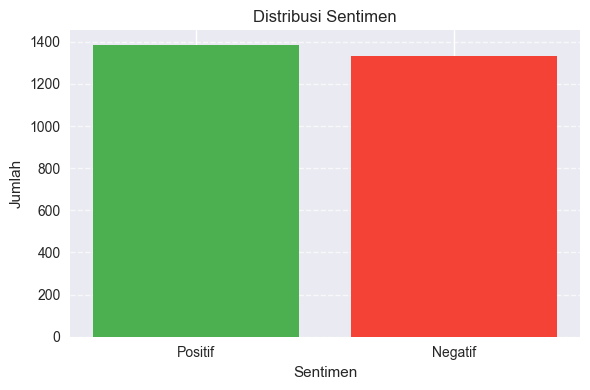

In [66]:
import matplotlib.pyplot as plt

# Data distribusi sentimen
labels = ['Positif', 'Negatif']
counts = [1385, 1334]
colors = ['#4CAF50', '#F44336']  # Hijau untuk positif, merah untuk negatif

# Membuat diagram batang
plt.figure(figsize=(6, 4))
plt.bar(labels, counts, color=colors)
plt.title('Distribusi Sentimen')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Tampilkan grafik
plt.show()

